In [20]:
from Program import *
import numpy as np
from matplotlib import pyplot

# Modelowanie układów przepływowych - Projekt
### Kostur Oleksandr Grupa 1

## Wpływ podłoża na siłe fali uderzeniowej


W danyp projekcie odpowiem na pytanie: Jak zależy siła wywierana falą na filar mostu w zależności od kształtu podłoża obok filaru ?


Początkowo  projekt polegał na sprawdzaniu jak kształt filaru zmienia przepływ, zainspirowany publikacją: <br>
<b><i>Tymiński, Tomasz. (2010). Hydraulic Model Research on Bridge Piers Based on the Example of Selected Bridges in Opole. Rocznik Ochrona Srodowiska. 12. 879-893.</i></b>
<br>
Jednak przez nieudaną próbę zaimplementowania warunków brzegowych pomysł ten pozostawiono na lepsze czasy.

Wychylenie cienkiej warstwy symulowanego płynu w postaci kosinusa pod wpływem grawitacji utworzy falę przemieszczającą się w kierunku $\vec{y}$. Realizacja odbędzie się na siatce $10 \times 10 [m]$. Warunki brzegowe stałe o wartości $0$.

Na końcu pudła obliczeniowego podłoże będzie zmodyfikowane dwoma gausami o zadanej amplitudzie $A$. Na końcu siatki ustawione będą poglądowo dwa filary w postaci prostopadłościanów o wymiarach $1\times 1 [m]$ oraz "nieskończonej" wysokości.

Uwzględniając zmienne dostępne w schemacie Shallow Water, pęd odcinka falowego będzie przeliczał się w następujący sposób:

$$ p(t) = \rho V(t) \frac{vh(t)}{h(t)}$$

W zadanym schemacie zmienne $vh, uh, h$ odpowiadają odpowiednio za prędkość w $\vec{x}, \vec{y}$ i wysokość, zależne są od trzech zmiennych $t,x_i,y_i$. W przypadku naszych obliczeń będziemy brać pod uwagę jedynie przekrój fali w ostatnim oczku $y_i=n_y$ dla $x$ w zakresie filaru. Uwzględniając ten fakt wartości $V, uh/h$ będą przeliczone w następujący sposób:

$$ V(t) = dy\sum_{x\in D} h(t, x, y=n_y)\cdot dx$$

$$ \frac{vh(t)}{h(t)} = \sum_{x\in D} \frac{vh(t, x, y=n_y)}{h(t, x, y=n_y)} $$

Ostatecznie pęd będzie wyrażony jako:

$$ p(t) = \rho dy\sum_{x \in D} [h(t, x, y=n_y)\cdot dx] \sum_{x \in D} \frac{vh(t, x, y=n_y)}{h(t, x, y=n_y)} = \rho dy\sum_{x \in D} dx\cdot vh(t, x, y=n_y)$$

Znając rozkład pędu, możemy przeliczyć go na siłę:
$$ F(t) = \frac{dp}{dt} = \frac{p(t) - p(t-dt)}{dt}$$

In [21]:
bathymetry = bathymetrys(grid := (60,60))
dt_over_dxy=(.2, .2)

### Zależność sił, pędów dla poszczególnych Amplitud


Na początek sprawdzimy, jak zachowuje się fala na płaskim dnie. 

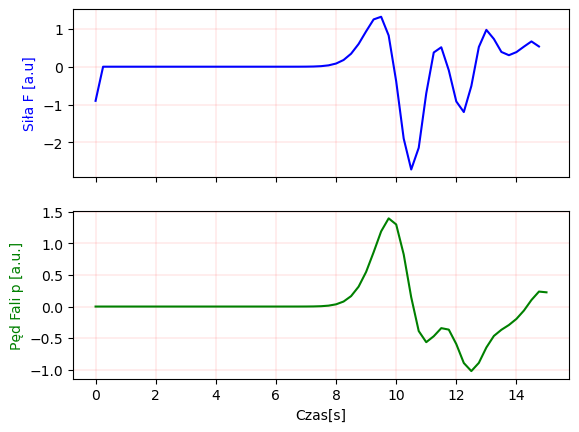

In [22]:
run0 = WaveByBathymetry(grid, bathymetry.flat(), dt_over_dxy)
plot_F_p_(run0, 'A= 0')

Mniejsze zafalowania po pierwszym piku występują w momencie gdy fala odbija się od granicy pudła (Obszar ten nie jest do końca fizycznie związany z założeniami filarów na końcach siatki ).

Zbadamy cztery podłoża o wypukłości gausowskiej o amplitudach $A \in \{ -0.15, 0.15, -0.30, 0.30\}$. Celem takiego rozkładu jest sprawdzenie jak wypukłość dna oraz wysokość tej wypukłości wpływa na fale.

In [23]:
run1 = WaveByBathymetry(grid, bathymetry.gauss_(-0.15), dt_over_dxy)
run2 = WaveByBathymetry(grid, bathymetry.gauss_(+0.15), dt_over_dxy)
run3 = WaveByBathymetry(grid, bathymetry.gauss_(-0.30), dt_over_dxy)
run4 = WaveByBathymetry(grid, bathymetry.gauss_(+0.30), dt_over_dxy)

Wykres zależności siły "działającej" na filar dla poszczególnych amplitud: 

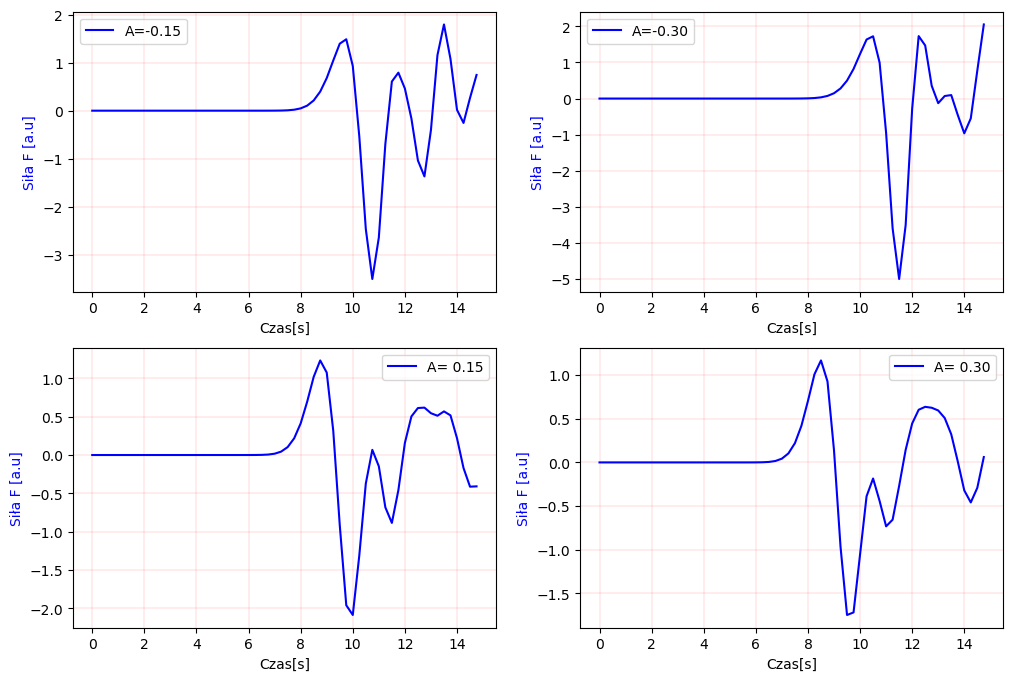

In [24]:
plot_F_4(run1, run2,run3,run4)

Wykres zależności pędu  na filar dla poszczególnych amplitud: 

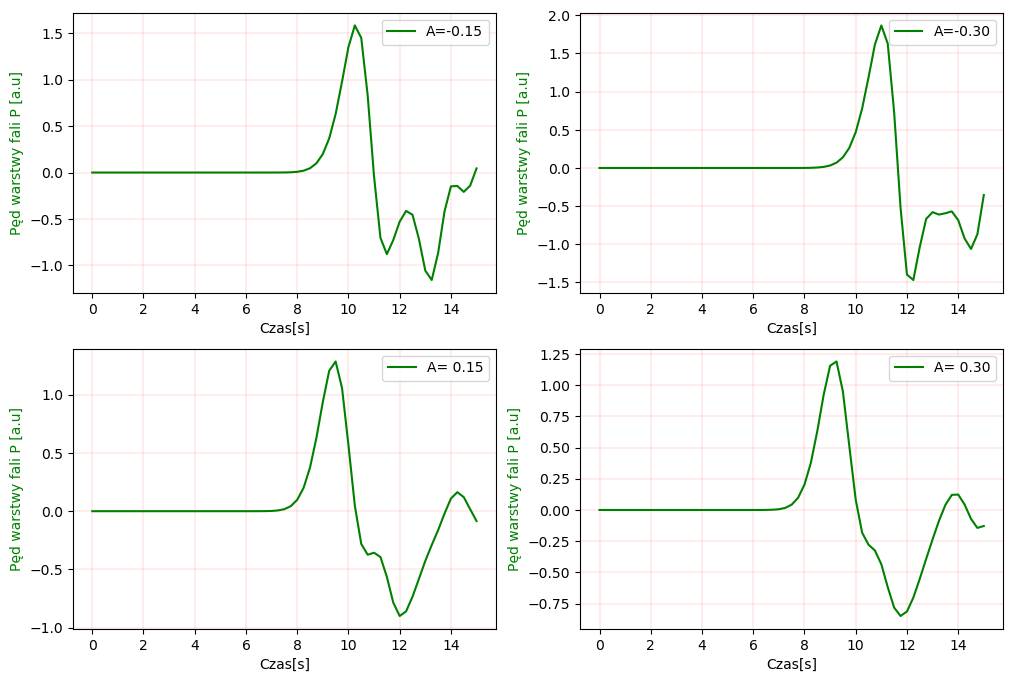

In [25]:
plot_P_4(run1, run2,run3,run4)

# Zbieżność dla zwiększonej siatki

Sprawdzimy jak zmienia się rozkład sił przy dwukrotnym zwiększeniu siatki w $y$.

In [31]:
bathymetry = bathymetrys(grid := (60,120))
run4 = WaveByBathymetry(grid, bathymetry.gauss_(+0.30), dt_over_dxy)

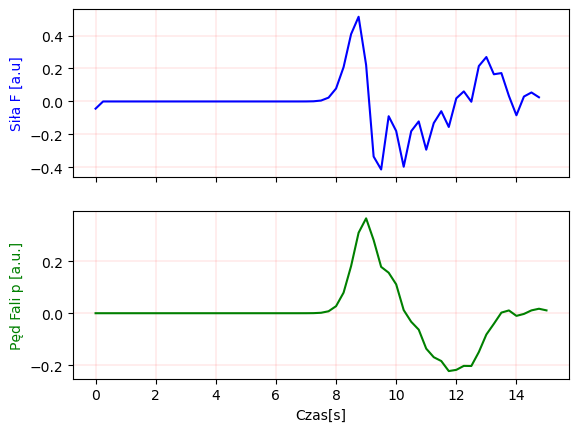

In [32]:
plot_F_p_(run4, 'A= .3')

Wymiary po zwiększeniu liczby oczek nie są zgadzają się. Dzieje się tak dla tego, że bierzemy pod uwagę jedynie ostatnią warstwę płynu, a zmwiększenie liczby oczek powoduję zmniejszenie objętości.
Kształt przebiegu finkcji siły dla zwiększonej siatki ma  większe zafalowania (bardziej wyostrzone piki).

## Wnioski

W ramach obliczeń modyfikacja dna w sposób gausowski nie wprowadza znaczących zmian w siłę wywieraną na filar. Na ogół ujemne amplitudy wykazały gorszą własność tłumienia fali uderzeniowej. A zwiększenie amplitudy nie



Artefakty zawierają symulację gif: przepływu zmiany prędkości i wysokości z czasem. 